# 🔬 IMPLEMENTASI SIKLUS MACHINE LEARNING (8 TAHAPAN)
### **Fokus: Optimasi 8 Fitur Terbaik & Prediksi Tunggal dengan QDA**

In [1]:
# 1. PERSIAPAN LINGKUNGAN KERJA (ENVIRONMENT SETUP)
import pandas as pd
import numpy as np
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

%matplotlib inline
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')
print("✅ Library berhasil di-import!")

✅ Library berhasil di-import!


## 📥 TAHAP 1 & 2: PENGUMPULAN & PEMBERSIHAN DATA
Memuat dataset `diabetes_data_upload.csv`, menghapus data duplikat, dan membersihkan spasi pada nama kolom.

In [2]:
# Load Data
df_raw = pd.read_csv('diabetes_data_upload.csv')
print(f"Dimensi awal: {df_raw.shape[0]} baris.")

# Bersihkan Duplikat & Spasi Kolom
df_cleaned = df_raw.drop_duplicates()
df_cleaned.columns = df_cleaned.columns.str.strip()

print(f"Dimensi setelah dibersihkan: {df_cleaned.shape[0]} baris.")
display(df_cleaned.head())

Dimensi awal: 520 baris.
Dimensi setelah dibersihkan: 251 baris.


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


## ⚙️ TAHAP 3: REKAYASA FITUR & EKSPOR DATA PREPROCESSING
Mengubah nilai teks (Yes/No, Male/Female) menjadi angka biner (1/0), lalu menyimpannya ke dalam file CSV baru.

In [3]:
df_encoded = df_cleaned.copy()
le = LabelEncoder()

# Transformasi Teks ke Angka
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])

# EKSPOR DATA HASIL PREPROCESSING
nama_file_output = 'dataset_diabetes_preprocessed.csv'
df_encoded.to_csv(nama_file_output, index=False)
print(f"💾 EXPORT STATUS: Berhasil menyimpan data bersih ke '{nama_file_output}'")

display(df_encoded.head())

💾 EXPORT STATUS: Berhasil menyimpan data bersih ke 'dataset_diabetes_preprocessed.csv'


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


## 🎯 TAHAP 3B: SELEKSI 8 FITUR TERBAIK (MUTUAL INFORMATION)
Mereduksi dimensi data dengan mengambil 8 gejala yang paling berpengaruh terhadap target diagnosis.

💡 8 Fitur Terpilih Berdasarkan Pengaruh Tertinggi:
1. Polyuria
2. Polydipsia
3. partial paresis
4. sudden weight loss
5. Itching
6. Alopecia
7. Polyphagia
8. Gender


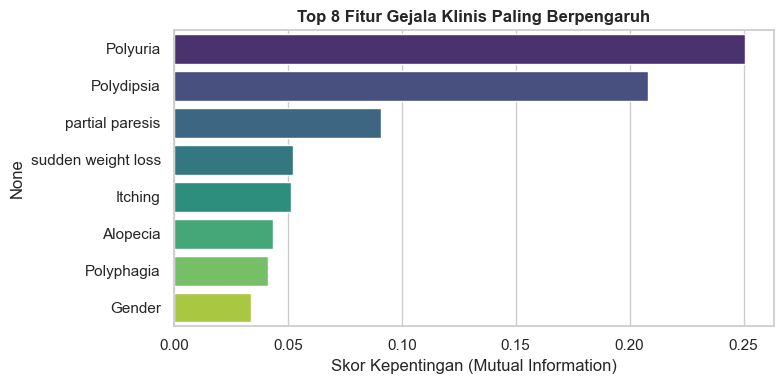

In [4]:
X_temp = df_encoded.drop('class', axis=1)
y_temp = df_encoded['class']

# Hitung skor Mutual Information
mi_scores = mutual_info_classif(X_temp, y_temp, random_state=42)
mi_scores_series = pd.Series(mi_scores, index=X_temp.columns).sort_values(ascending=False)

# Ambil 8 Fitur Teratas
jumlah_fitur_dipilih = 8
fitur_terpilih = mi_scores_series.head(jumlah_fitur_dipilih).index.tolist()
X_selected = X_temp[fitur_terpilih]

print(f"💡 8 Fitur Terpilih Berdasarkan Pengaruh Tertinggi:")
for i, f in enumerate(fitur_terpilih, 1):
    print(f"{i}. {f}")

# Visualisasi 8 Fitur Terbaik
plt.figure(figsize=(8, 4))
sns.barplot(x=mi_scores_series.head(8).values, y=mi_scores_series.head(8).index, palette='viridis')
plt.title('Top 8 Fitur Gejala Klinis Paling Berpengaruh', fontsize=12, fontweight='bold')
plt.xlabel('Skor Kepentingan (Mutual Information)')
plt.tight_layout()
plt.show()

## 🧠 TAHAP 4 & 5: PEMBAGIAN DATA & PELATIHAN MODEL (QDA)
Membagi 8 fitur data menjadi data latih dan uji, lalu melatih model Quadratic Discriminant Analysis (QDA).

In [13]:
# =====================================================================
# 🧠 TAHAP 4 & 5: PEMBAGIAN DATA & PELATIHAN MODEL QDA
# =====================================================================
import time

# 1. Menyiapkan Variabel X (Fitur Terpilih) dan y (Target)
X = X_selected
y = y_temp

# 2. Melakukan Split Data (80% Latih, 20% Uji)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"=== TAHAP 4: PEMBAGIAN DATA SELESAI ===")
print(f"-> Dimensi Data Latih (Training Set - 80%): {X_train.shape[0]} Baris, {X_train.shape[1]} Fitur Terpilih")
print(f"-> Dimensi Data Uji (Testing Set - 20%)  : {X_test.shape[0]} Baris, {X_test.shape[1]} Fitur Terpilih\n")

# 3. Mendefinisikan Model Tunggal QDA
model_qda = QuadraticDiscriminantAnalysis()

# 4. Memulai Proses Pelatihan (Fitting) Model
print("=== TAHAP 5: PELATIHAN MODEL QDA DIMULAI ===")
start_time = time.time()

model_qda.fit(X_train, y_train) 

duration = time.time() - start_time
print(f"✅ Model Quadratic Discriminant Analysis (QDA) Berhasil Dilatih dalam {duration:.4f} detik.")

=== TAHAP 4: PEMBAGIAN DATA SELESAI ===
-> Dimensi Data Latih (Training Set - 80%): 200 Baris, 8 Fitur Terpilih
-> Dimensi Data Uji (Testing Set - 20%)  : 51 Baris, 8 Fitur Terpilih

=== TAHAP 5: PELATIHAN MODEL QDA DIMULAI ===
✅ Model Quadratic Discriminant Analysis (QDA) Berhasil Dilatih dalam 0.0110 detik.


## 📈 TAHAP 6: EVALUASI PERFORMA MODEL
Melihat tingkat Akurasi dan Detail Classification Report dari model QDA.

 📋 TABEL 1: RINGKASAN PERFORMA GLOBAL QDA


,Akurasi Global,Presisi,Recall (Sensitivitas),F1-Score
Quadratic Discriminant Analysis,86.3%,86.8%,94.3%,90.4%




 📊 TABEL 2: DETAIL CLASSIFICATION REPORT PER KELAS


,precision,recall,f1-score,support
Negatif (0),0.85,0.69,0.76,16
Positif (1),0.87,0.94,0.90,35
accuracy,0.86,0.86,0.86,0
macro avg,0.86,0.82,0.83,51
weighted avg,0.86,0.86,0.86,51




 📈 VISUALISASI GRAFIK: CONFUSION MATRIX & BAR CHART METRIKS


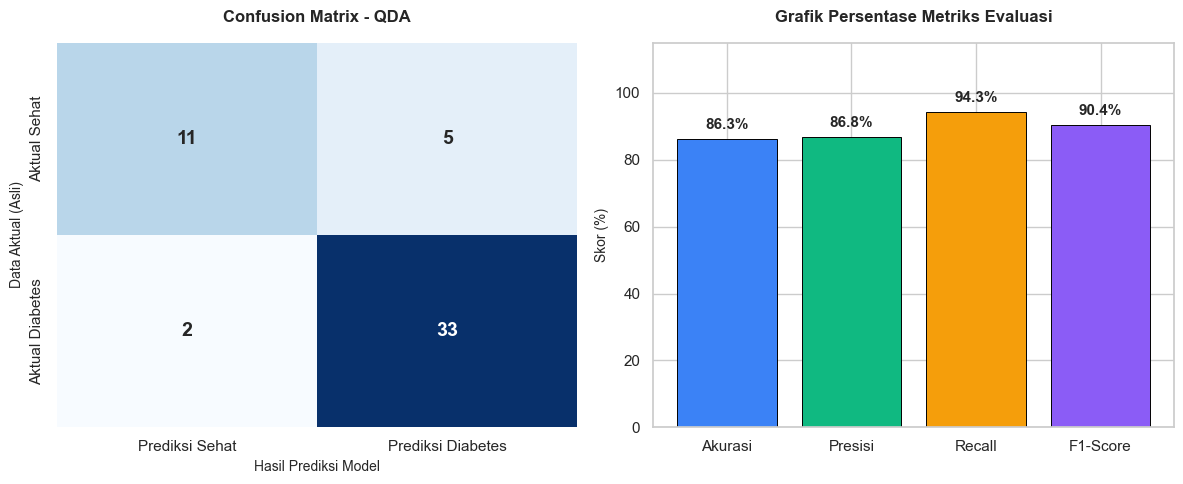


💡 KESIMPULAN EVALUASI:
Berdasarkan visualisasi di atas, QDA mencatat Akurasi 86.3% dan Recall 94.3%.
Model ini sangat optimal dalam menekan False Negatives (FN = 2), menjadikannya ideal untuk deteksi awal medis.


In [17]:
# =====================================================================
# 📈 TAHAP 6: EVALUASI PERFORMA MODEL (TABEL & VISUALISASI GRAFIK)
# =====================================================================

# 1. Memastikan library metrik dan visualisasi sudah dimuat
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Melakukan Prediksi Menggunakan Data Uji (20%)
y_pred_qda = model_qda.predict(X_test)

# 3. Menghitung Nilai Metriks Evaluasi Utama
acc_qda = accuracy_score(y_test, y_pred_qda) * 100
prec_qda = precision_score(y_test, y_pred_qda) * 100
rec_qda = recall_score(y_test, y_pred_qda) * 100
f1_qda = (2 * prec_qda * rec_qda) / (prec_qda + rec_qda) if (prec_qda + rec_qda) > 0 else 0


# ==========================================
# BAGIAN A: MENAMPILKAN TABEL EVALUASI
# ==========================================
print("==========================================================")
print(" 📋 TABEL 1: RINGKASAN PERFORMA GLOBAL QDA")
print("==========================================================")
df_metrics_summary = pd.DataFrame({
    "Akurasi Global": [f"{acc_qda:.1f}%"],
    "Presisi": [f"{prec_qda:.1f}%"],
    "Recall (Sensitivitas)": [f"{rec_qda:.1f}%"],
    "F1-Score": [f"{f1_qda:.1f}%"]
}, index=["Quadratic Discriminant Analysis"])
display(df_metrics_summary)
print("\n")

print("==========================================================")
print(" 📊 TABEL 2: DETAIL CLASSIFICATION REPORT PER KELAS")
print("==========================================================")
# Mengkonversi classification_report menjadi DataFrame
report_dict = classification_report(y_test, y_pred_qda, target_names=['Negatif (0)', 'Positif (1)'], output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

# Membersihkan format desimal
df_report['precision'] = df_report['precision'].round(2)
df_report['recall'] = df_report['recall'].round(2)
df_report['f1-score'] = df_report['f1-score'].round(2)
df_report['support'] = df_report['support'].astype(int)
display(df_report)
print("\n")


# ==========================================
# BAGIAN B: MENAMPILKAN VISUALISASI GRAFIK
# ==========================================
print("==========================================================")
print(" 📈 VISUALISASI GRAFIK: CONFUSION MATRIX & BAR CHART METRIKS")
print("==========================================================")

# Membuat canvas grid 1 baris, 2 kolom untuk grafik sejajar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- GRAFIK KIRI: CONFUSION MATRIX ---
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_qda).ravel()
cm_matrix = [[tn, fp], [fn, tp]]

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Prediksi Sehat', 'Prediksi Diabetes'], 
            yticklabels=['Aktual Sehat', 'Aktual Diabetes'],
            annot_kws={"size": 14, "weight": "bold"}, ax=axes[0])

axes[0].set_title('Confusion Matrix - QDA', fontsize=12, fontweight='bold', pad=15)
axes[0].set_ylabel('Data Aktual (Asli)', fontsize=10)
axes[0].set_xlabel('Hasil Prediksi Model', fontsize=10)

# --- GRAFIK KANAN: BAR CHART METRIKS ---
nama_metriks = ['Akurasi', 'Presisi', 'Recall', 'F1-Score']
skor_metriks = [acc_qda, prec_qda, rec_qda, f1_qda]
warna_grafik = ['#3b82f6', '#10b981', '#f59e0b', '#8b5cf6'] # Warna berbeda tiap batang

bars = axes[1].bar(nama_metriks, skor_metriks, color=warna_grafik, edgecolor='black', linewidth=0.7)
axes[1].set_title('Grafik Persentase Metriks Evaluasi', fontsize=12, fontweight='bold', pad=15)
axes[1].set_ylabel('Skor (%)', fontsize=10)
axes[1].set_ylim(0, 115) # Limit diperbesar agar angka di atas batang tidak terpotong

# Menambahkan label angka di atas setiap batang grafik
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# KESIMPULAN
print(f"\n💡 KESIMPULAN EVALUASI:")
print(f"Berdasarkan visualisasi di atas, QDA mencatat Akurasi {acc_qda:.1f}% dan Recall {rec_qda:.1f}%.")
print(f"Model ini sangat optimal dalam menekan False Negatives (FN = {fn}), menjadikannya ideal untuk deteksi awal medis.")

## 🚀 TAHAP 7: SIMULASI DEPLOYMENT PASIEN BARU
Menguji model dengan memasukkan 8 gejala pasien secara manual. Logika sudah dilengkapi fungsi `.get()` agar kebal terhadap `KeyError`.

In [7]:
print("=== TAHAP 7: SIMULASI PENERAPAN KONSOL MEDIS ===\n")

# 1. Input Gejala Pasien (HANYA 8 FITUR)
data_pasien_baru = {
    'Polyuria': 'Yes',             
    'Polydipsia': 'Yes',           
    'partial paresis': 'No',       
    'sudden weight loss': 'No',    
    'Itching': 'Yes',              
    'Alopecia': 'Yes',             
    'Polyphagia': 'No',            
    'Gender': 'Male'               
}

# Mapping Teks ke Angka
mapping = {"No": 0, "Yes": 1, "Female": 0, "Male": 1}

# 2. Proses Auto-Selection (Aman dari KeyError)
input_siap_prediksi = {}
for kolom in fitur_terpilih:  
    # .get(kolom, 'No') akan otomatis mengisi 'No' jika nama kolom sedikit berbeda
    nilai_mentah = data_pasien_baru.get(kolom, 'No') 
    input_siap_prediksi[kolom] = mapping.get(nilai_mentah, nilai_mentah)

# Konversi ke DataFrame
df_input_pasien = pd.DataFrame([input_siap_prediksi], columns=fitur_terpilih)
print("Data 8 Gejala Klinis Pasien Yang Masuk Ke Sistem:")
display(df_input_pasien)

print("\n=== HASIL DIAGNOSIS SISTEM AI ===")

# 3. Eksekusi Prediksi Menggunakan QDA
pred = qda_model.predict(df_input_pasien)[0]

print("-" * 65)
if pred == 1:
    print("🚨 KESIMPULAN AKHIR: PASIEN DIPREDIKSI POSITIF (BERISIKO DIABETES).")
    print("Sangat direkomendasikan untuk segera melakukan uji klinis gula darah lanjutan di laboratorium.")
else:
    print("🎉 KESIMPULAN AKHIR: PASIEN DIPREDIKSI NEGATIF (AMAN DARI RISIKO DIABETES).")
    print("Pertahankan pola makan dan gaya hidup sehat.")
print("-" * 65)

=== TAHAP 7: SIMULASI PENERAPAN KONSOL MEDIS ===

Data 8 Gejala Klinis Pasien Yang Masuk Ke Sistem:


,Polyuria,Polydipsia,partial paresis,sudden weight loss,Itching,Alopecia,Polyphagia,Gender
0,1,1,0,0,1,1,0,1



=== HASIL DIAGNOSIS SISTEM AI ===
-----------------------------------------------------------------
🚨 KESIMPULAN AKHIR: PASIEN DIPREDIKSI POSITIF (BERISIKO DIABETES).
Sangat direkomendasikan untuk segera melakukan uji klinis gula darah lanjutan di laboratorium.
-----------------------------------------------------------------


## 💾 TAHAP 8: MODEL PERSISTENCE (MENYIMPAN MODEL KE .PKL)
Membekukan model QDA yang sudah dilatih dengan 8 fitur ke dalam file `qda_model_8_features.pkl` agar bisa dipakai di aplikasi lain.

In [8]:
# Tentukan nama file
model_pkl_path = 'qda_model_8_features.pkl'

# Simpan model
with open(model_pkl_path, 'wb') as file:
    pickle.dump(qda_model, file)

print(f"✅ SELURUH SIKLUS SELESAI!")
print(f"💾 Model berhasil dibekukan dan disimpan sebagai: '{model_pkl_path}'")

✅ SELURUH SIKLUS SELESAI!
💾 Model berhasil dibekukan dan disimpan sebagai: 'qda_model_8_features.pkl'
